In [61]:
import pandas as pd
from sklearn.neighbors import sort_graph_by_row_values

pd.set_option('display.max_columns', None)
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

import config
from data_utils import sort_data

In [62]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [63]:
data.shape

(20820, 105)

In [64]:
data.head()

,web_name_id,first_name_id,second_name_id,status_id,team_name_id,position_id,season_id,player_code_id,team_code_id,gw_id,match_id,recoveries,dreamteam_count,creativity,tackles_won_percent,corners_and_indirect_freekicks_order,bps,accurate_passes,transfers_in,expected_goals_conceded,ground_duels_won,duels_lost,tackles_won,finish_min,xgot,ep_this,was_fouled,accurate_long_balls_percent,accurate_passes_percent,ground_duels_won_percent,transfers_out,touches,tackles,interceptions,event_points,transfers_out_event,clearances,gk_accurate_long_balls,now_cost_rank,goals,team_goals_conceded,value_form,fouls_committed,threat,penalties_missed,bonus,blocks,high_claim,ep_next,shots_on_target,value_season,minutes_played,dribbled_past,expected_goals,influence,now_cost,chance_of_playing_next_round,penalties_scored,cost_change_start,ict_index,id,touches_opposition_box,cost_change_event,selected_rank,penalties_order,form,selected_by_percent,expected_assists,accurate_crosses,start_min,team_strength,final_third_passes,accurate_long_balls,aerial_duels_won,offsides,total_shots,total_points,expected_goal_involvements,xa,aerial_duels_won_percent,goals_prevented,chances_created,goals_conceded,xgot_faced,direct_freekicks_order,gk_accurate_passes,successful_dribbles,headed_clearances,big_chances_missed,saves,sweeper_actions,duels_won,accurate_crosses_percent,successful_dribbles_percent,assists,xg,transfers_in_event,chance_of_playing_this_round,position,xg_per_90,xa_per_90,expected_goal_involvements_per_90,expected_goals_conceded_per_90,was_home,value_ratio
0,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,1,24-25-prem-everton-vs-brighton-&-hove-albion,0,0,43.8,50,1,10,28,513,0.45,4,2,2,82,0.0,1.6,0,33,85,80,421,48,4,0,2,421,0,0,172,0,0,0.4,1,4,0,0,2,0,1.6,0,0.4,82,0,0.0,22.4,5.0,0,0,0,7.0,134,2,0,471,6,2.0,0.1,0.11,2,0,3,2,1,0,0,0,2,0.11,0.11,0,0.0,3,0,0.0,7,0,0,0,0,0,0,4,29,0,0,0.0,513,0,MID,0.0,0.120732,0.120732,0.493902,False,0.4
1,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,2,24-25-prem-brighton-&-hove-albion-vs-mancheste...,2,0,66.2,0,1,22,22,2267,1.77,3,1,0,73,0.0,2.0,1,0,73,75,1548,42,1,1,2,635,2,0,177,0,1,0.4,1,12,0,0,0,0,1.0,1,0.8,73,0,0.16,28.6,5.0,0,0,0,10.7,134,2,0,448,6,2.0,0.1,0.15,1,0,3,6,0,0,0,2,4,0.31,0.04,0,0.0,1,0,0.0,7,0,1,0,0,0,0,3,100,100,0,0.16,1189,0,MID,0.19726,0.049315,0.382192,2.182192,True,0.4
2,Milner,James,Milner,d,Brighton,Midfielder,2425,15157,36,3,24-25-prem-arsenal-vs-brighton-&-hove-albion,0,0,66.3,0,1,24,2,4199,1.98,0,1,0,17,0.0,0.7,0,0,100,0,4535,4,0,1,1,1998,0,0,185,0,0,0.3,1,12,0,0,0,0,1.7,0,1.0,17,0,0.16,28.6,5.0,75,0,0,10.7,134,0,0,461,6,1.7,0.1,0.15,0,0,3,0,0,0,0,0,5,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,472,0,MID,0.0,0.0,1.641176,10.482353,False,0.2
3,Milner,James,Milner,a,Brighton,Midfielder,2425,15157,36,38,24-25-prem-tottenham-hotspur-vs-brighton-&-hov...,0,0,66.3,0,8,27,0,5014,1.98,0,0,0,93,0.0,0.0,0,0,0,0,10991,1,0,0,1,0,0,0,192,0,0,0.0,0,12,0,0,0,0,0.0,0,1.2,1,0,0.16,28.6,5.0,100,0,0,10.7,134,0,0,586,6,0.2,0.0,0.15,0,93,3,1,0,0,0,0,6,0.31,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,0,0,MID,0.0,0.0,27.9,178.2,False,0.2
4,Milner,James,Milner,a,Brighton,Midfielder,2526,15157,36,1,25-26-prem-brighton-hove-albion-vs-fulham,0,0,0.1,0,5,3,1,14413,0.24,0,0,0,90,0.0,0.0,0,0,0,0,20304,1,0,0,1,497,0,0,283,0,1,0.0,0,0,0,0,0,0,-0.5,0,3.1,2,0,0.0,0.0,4.9,100,0,-1,0.0,170,0,0,467,1,0.0,0.1,0.0,0,0,3,0,0,0,0,0,1,0.0,0.0,0,0.0,0,0,0.0,7,0,0,0,0,0,0,0,0,0,0,0.0,113,0,MID,0.0,0.0,0.0,10.8,True,0.204082


In [65]:
data.isna().sum().sum()

np.int64(0)

In [66]:
data.drop(columns="total_points", inplace=True)

In [67]:
[c for c in data.columns if "_id" in c]

['web_name_id',
 'first_name_id',
 'second_name_id',
 'status_id',
 'team_name_id',
 'position_id',
 'season_id',
 'player_code_id',
 'team_code_id',
 'gw_id',
 'match_id']

In [68]:
all_cols = set(data.columns)

rules = {
    "target": ["event_points"],
    "cols_id": [c for c in data.columns if "_id" in c],
    "static_cols": ['position', 'team_strength', "was_home", "status"],
    "order_cols": ['now_cost', 'order', 'chance_of_playing', "rank"],
    "ratio_features": ['percent', 'per_90']
}

categories = {key: [] for key in rules}
remaining_cols = all_cols.copy()

for category, keywords in rules.items():
    matched = [
        c for c in remaining_cols
        if any(k in c for k in keywords)
    ]
    categories[category] = matched
    remaining_cols -= set(matched)

performance_cols = list(remaining_cols) + ["touches_opposition_box"]

target = categories["target"]
cols_id = [c for c in categories["cols_id"] if c != "offsides"]
static_cols = [c for c in categories["static_cols"] if c != "touches_opposition_box"]
order_cols = categories["order_cols"]
ratio_features = categories["ratio_features"]


cols_to_lag = performance_cols + categories["order_cols"]
cols_to_ema = performance_cols+order_cols+ratio_features

In [69]:
data.shape[1], len(target + cols_id + static_cols + order_cols + ratio_features + performance_cols)

(104, 104)

In [70]:
def ema(df:pd.DataFrame,
        cols_to_lag:list[str] | None,
        window_size:int=4)->tuple[pd.DataFrame, list[str]]:

    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    ema_frame = df.groupby(["player_code_id", "season_id"])[cols_to_lag].transform(lambda x: x.ewm(span=window_size, adjust=False).mean().shift(1))

    new_cols = [f"{c}_ema_{window_size}" for c in cols_to_lag]
    df[new_cols] = ema_frame.fillna(0)
    return df, new_cols


In [71]:
def lagged_features(df:pd.DataFrame,
                    cols_to_lag:list[str] | None,
                    lag_size:int=1)->tuple[pd.DataFrame, list[str]]:
    if cols_to_lag is None:
        return df.copy(), []

    df = sort_data(df)

    lagged_frame = df.groupby(["player_code_id", "season_id"])[cols_to_lag].transform(lambda x: x.shift(lag_size))
    new_cols = [f"{c}_lagged_{lag_size}" for c in cols_to_lag]
    df[new_cols] = lagged_frame.fillna(0)

    return df, new_cols

In [72]:
data_ema, ema_cols = ema(df=data,
                        cols_to_lag=cols_to_ema+target,
                        window_size=8)


In [73]:
data_lagged, lagged_cols = lagged_features(df=data_ema,
                        cols_to_lag=cols_to_lag+target)


In [74]:
data_lagged.shape

(20820, 272)

In [75]:
features_to_keep = list(set(
    cols_id +
    static_cols +
    ema_cols +
    lagged_cols +
    target

))

In [76]:
data_lagged = data_lagged[[c for c in features_to_keep if c in data_lagged.columns]].copy()

In [77]:
data_lagged.shape

(20820, 183)

In [78]:
data_lagged.head()

,second_name_id,goals_prevented_ema_8,cost_change_event_lagged_1,transfers_in_event_lagged_1,accurate_crosses_lagged_1,offsides_lagged_1,accurate_long_balls_ema_8,accurate_passes_percent_ema_8,blocks_lagged_1,status_id,dreamteam_count_ema_8,expected_goals_ema_8,ep_next_ema_8,transfers_out_event_ema_8,xg_lagged_1,penalties_missed_lagged_1,id_lagged_1,first_name_id,xgot_lagged_1,assists_lagged_1,bonus_lagged_1,cost_change_event_ema_8,saves_ema_8,penalties_order_ema_8,expected_goals_lagged_1,gk_accurate_passes_lagged_1,high_claim_ema_8,finish_min_lagged_1,accurate_long_balls_percent_ema_8,fouls_committed_ema_8,form_lagged_1,cost_change_start_ema_8,chance_of_playing_next_round_ema_8,xg_ema_8,event_points,chance_of_playing_this_round_lagged_1,selected_rank_lagged_1,was_fouled_lagged_1,chances_created_lagged_1,value_ratio_lagged_1,gk_accurate_long_balls_lagged_1,position,successful_dribbles_ema_8,goals_ema_8,touches_opposition_box_ema_8,now_cost_lagged_1,value_season_ema_8,transfers_in_lagged_1,team_code_id,direct_freekicks_order_lagged_1,start_min_ema_8,gk_accurate_long_balls_ema_8,ground_duels_won_ema_8,interceptions_ema_8,shots_on_target_ema_8,xgot_faced_ema_8,recoveries_lagged_1,now_cost_rank_ema_8,value_season_lagged_1,xa_ema_8,threat_ema_8,big_chances_missed_ema_8,sweeper_actions_ema_8,expected_goals_conceded_lagged_1,ict_index_lagged_1,touches_lagged_1,offsides_ema_8,penalties_scored_lagged_1,aerial_duels_won_percent_ema_8,corners_and_indirect_freekicks_order_ema_8,direct_freekicks_order_ema_8,accurate_crosses_percent_ema_8,finish_min_ema_8,bps_ema_8,minutes_played_lagged_1,xg_per_90_ema_8,final_third_passes_ema_8,shots_on_target_lagged_1,event_points_lagged_1,bonus_ema_8,xgot_faced_lagged_1,value_ratio_ema_8,expected_goals_conceded_per_90_ema_8,ep_this_ema_8,sweeper_actions_lagged_1,id_ema_8,high_claim_lagged_1,tackles_ema_8,event_points_ema_8,web_name_id,influence_ema_8,team_goals_conceded_lagged_1,value_form_lagged_1,penalties_scored_ema_8,transfers_in_event_ema_8,accurate_crosses_ema_8,bps_lagged_1,position_id,accurate_passes_lagged_1,gk_accurate_passes_ema_8,headed_clearances_ema_8,goals_conceded_ema_8,xa_per_90_ema_8,ep_this_lagged_1,dribbled_past_lagged_1,aerial_duels_won_ema_8,dreamteam_count_lagged_1,creativity_lagged_1,transfers_out_lagged_1,duels_won_ema_8,goals_lagged_1,final_third_passes_lagged_1,dribbled_past_ema_8,expected_goal_involvements_per_90_ema_8,xgot_ema_8,team_goals_conceded_ema_8,was_fouled_ema_8,match_id,ep_next_lagged_1,duels_won_lagged_1,team_name_id,blocks_ema_8,form_ema_8,cost_change_start_lagged_1,recoveries_ema_8,big_chances_missed_lagged_1,saves_lagged_1,creativity_ema_8,now_cost_ema_8,chance_of_playing_next_round_lagged_1,team_strength,ict_index_ema_8,minutes_played_ema_8,transfers_in_ema_8,corners_and_indirect_freekicks_order_lagged_1,goals_conceded_lagged_1,touches_ema_8,clearances_lagged_1,total_shots_ema_8,selected_rank_ema_8,value_form_ema_8,assists_ema_8,tackles_lagged_1,tackles_won_lagged_1,aerial_duels_won_lagged_1,ground_duels_won_percent_ema_8,penalties_missed_ema_8,duels_lost_ema_8,transfers_out_ema_8,tackles_won_percent_ema_8,expected_assists_ema_8,transfers_out_event_lagged_1,now_cost_rank_lagged_1,clearances_ema_8,ground_duels_won_lagged_1,expected_assists_lagged_1,expected_goals_conceded_ema_8,expected_goal_involvements_lagged_1,chance_of_playing_this_round_ema_8,tackles_won_ema_8,was_home,start_min_lagged_1,touches_opposition_box_lagged_1,penalties_order_lagged_1,gw_id,selected_by_percent_ema_8,headed_clearances_lagged_1,duels_lost_lagged_1,season_id,total_shots_lagged_1,accurate_passes_ema_8,expected_goal_involvements_ema_8,xa_lagged_1,accurate_long_balls_lagged_1,successful_dribbles_lagged_1,successful_dribbles_percent_ema_8,chances_created_ema_8,goals_prevented_lagged_1,fouls_committed_lagged_1,interceptions_lagged_1,threat_lagged_1,influence_lagged_1,player_code_id
0,Milner,0.0,0,0,0,0,0.000000,0.000000,0,a,0.0,0.000000,0.000000,0.000000,0.0,0,0,James,0.0,0,0,0.0,0.0,0.0,0

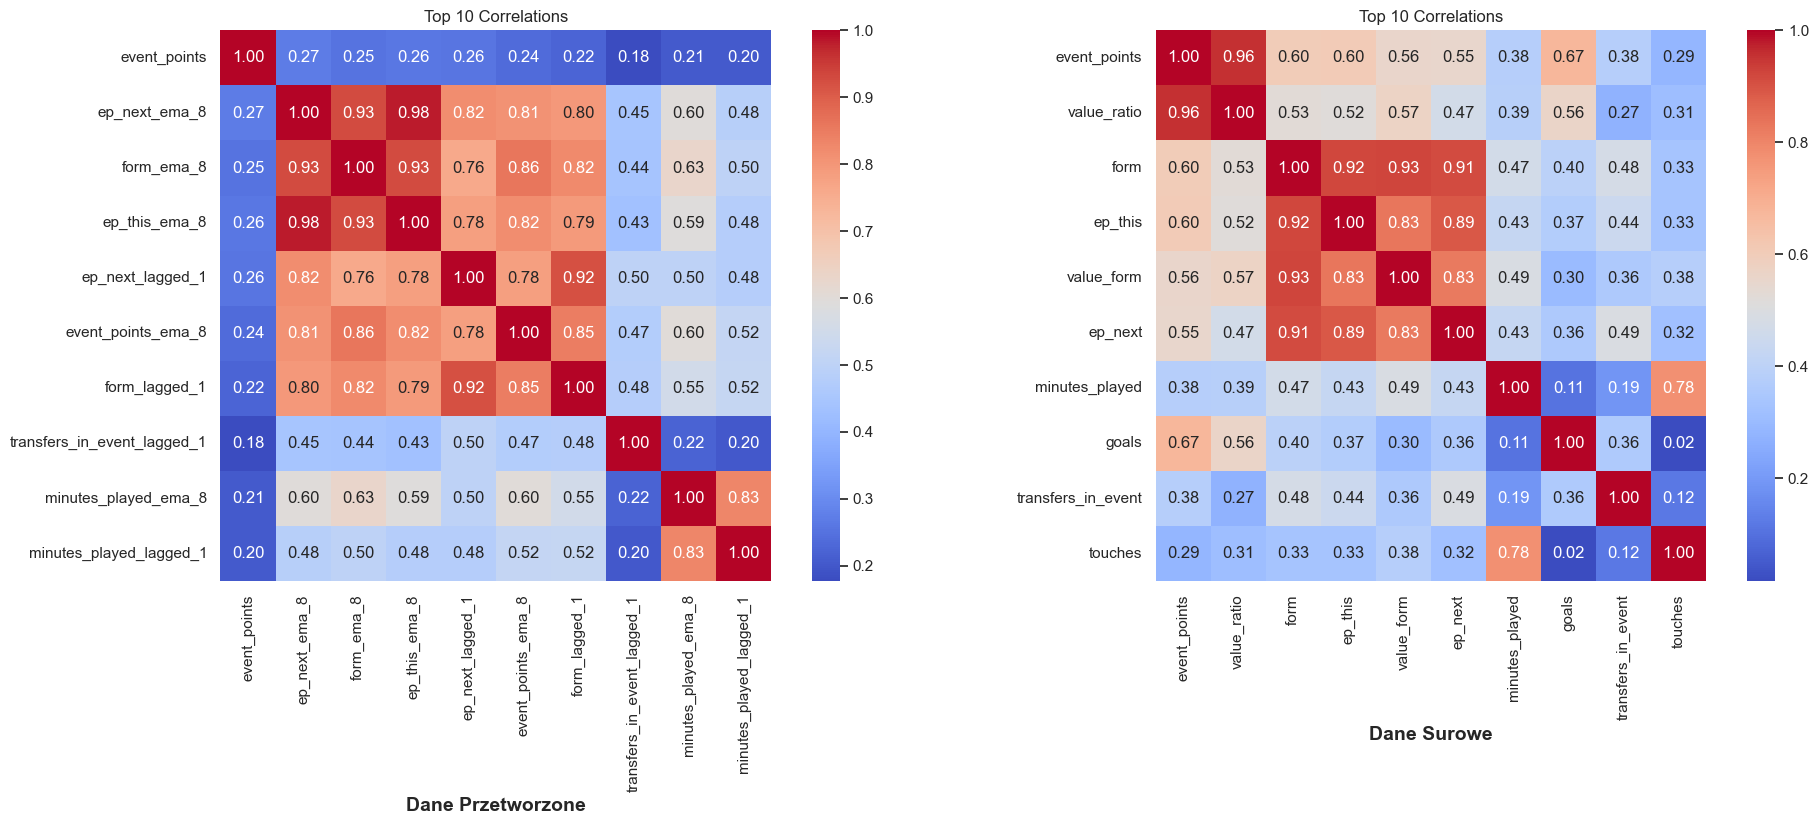

In [79]:
def corr_heatmaps(frames: list[pd.DataFrame], titles: list[str]) -> plt.Figure:
    fig, axes = plt.subplots(1, len(frames), figsize=(10 * len(frames), 8))
    if len(frames) == 1: axes = [axes]

    for ax, df, title in zip(axes, frames, titles):
        top_cols = df.select_dtypes(include=np.number).corr("spearman")["event_points"].abs().nlargest(10).index

        sns.heatmap(df[top_cols].corr(), annot=True, cmap="coolwarm", ax=ax,
                    square=True, fmt=".2f")

        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.set_title(f"Top 10 Correlations")
        ax.set_xlabel(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    return fig

fig = corr_heatmaps([data_lagged, data], ["Dane Przetworzone", "Dane Surowe"])

In [80]:
def over_corr_pairs(df: pd.DataFrame, threshold: float = 0.9) -> list[tuple[str, str, float]]:
    corr_matrix = df.select_dtypes(include=np.number).corr().abs()
    upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pairs = []
    for col in upper_tri.columns:
        correlated_with = upper_tri[col][upper_tri[col] > threshold]
        for idx, val in correlated_with.items():
            pairs.append((idx, col, round(val, 4)))

    return pairs


In [81]:
pairs = over_corr_pairs(data_lagged, 0.95)
pairs

[('expected_goals_ema_8', 'expected_goals_lagged_1', 0.9927),
 ('value_season_ema_8', 'value_season_lagged_1', 0.9743),
 ('expected_goals_ema_8', 'threat_ema_8', 0.9548),
 ('direct_freekicks_order_lagged_1', 'direct_freekicks_order_ema_8', 0.9734),
 ('value_ratio_lagged_1', 'event_points_lagged_1', 0.9571),
 ('bonus_lagged_1', 'bonus_ema_8', 0.9867),
 ('ep_next_ema_8', 'ep_this_ema_8', 0.9811),
 ('id_lagged_1', 'id_ema_8', 1.0),
 ('bps_ema_8', 'bps_lagged_1', 0.9873),
 ('gk_accurate_passes_lagged_1', 'gk_accurate_passes_ema_8', 0.9622),
 ('xgot_faced_ema_8', 'goals_conceded_ema_8', 0.9681),
 ('dreamteam_count_ema_8', 'dreamteam_count_lagged_1', 0.9824),
 ('cost_change_start_ema_8', 'cost_change_start_lagged_1', 0.9536),
 ('creativity_lagged_1', 'creativity_ema_8', 0.994),
 ('now_cost_lagged_1', 'now_cost_ema_8', 0.9993),
 ('chance_of_playing_this_round_lagged_1',
  'chance_of_playing_next_round_lagged_1',
  0.9591),
 ('ict_index_lagged_1', 'ict_index_ema_8', 0.9946),
 ('bps_ema_8', 'ic

In [82]:
worst_cols = data.select_dtypes(include=np.number).corr()["event_points"].abs()
lowest_corr_cols_to_drop = [c for c in worst_cols[worst_cols<.5].index if c not in cols_id+static_cols]

In [83]:
len(pairs)

41

In [84]:
for col1, col2, _ in pairs:
    if col1 in data_lagged.columns and col2 in data_lagged.columns:
        data_lagged.drop(columns=col1, inplace=True)

In [85]:
data_lagged.drop(columns=[c for c in lowest_corr_cols_to_drop if c in data_lagged.columns], inplace=True)

In [86]:
data_lagged.shape

(20820, 152)

In [87]:
data_lagged.head()

,second_name_id,goals_prevented_ema_8,cost_change_event_lagged_1,transfers_in_event_lagged_1,accurate_crosses_lagged_1,offsides_lagged_1,accurate_long_balls_ema_8,accurate_passes_percent_ema_8,blocks_lagged_1,status_id,transfers_out_event_ema_8,xg_lagged_1,penalties_missed_lagged_1,first_name_id,xgot_lagged_1,assists_lagged_1,cost_change_event_ema_8,saves_ema_8,high_claim_ema_8,finish_min_lagged_1,accurate_long_balls_percent_ema_8,fouls_committed_ema_8,form_lagged_1,xg_ema_8,event_points,was_fouled_lagged_1,chances_created_lagged_1,gk_accurate_long_balls_lagged_1,position,successful_dribbles_ema_8,goals_ema_8,touches_opposition_box_ema_8,team_code_id,start_min_ema_8,gk_accurate_long_balls_ema_8,ground_duels_won_ema_8,interceptions_ema_8,shots_on_target_ema_8,recoveries_lagged_1,value_season_lagged_1,xa_ema_8,big_chances_missed_ema_8,sweeper_actions_ema_8,touches_lagged_1,offsides_ema_8,penalties_scored_lagged_1,aerial_duels_won_percent_ema_8,direct_freekicks_order_ema_8,accurate_crosses_percent_ema_8,finish_min_ema_8,minutes_played_lagged_1,xg_per_90_ema_8,final_third_passes_ema_8,shots_on_target_lagged_1,event_points_lagged_1,bonus_ema_8,xgot_faced_lagged_1,value_ratio_ema_8,expected_goals_conceded_per_90_ema_8,ep_this_ema_8,sweeper_actions_lagged_1,id_ema_8,high_claim_lagged_1,tackles_ema_8,event_points_ema_8,web_name_id,team_goals_conceded_lagged_1,value_form_lagged_1,penalties_scored_ema_8,transfers_in_event_ema_8,accurate_crosses_ema_8,bps_lagged_1,position_id,accurate_passes_lagged_1,gk_accurate_passes_ema_8,headed_clearances_ema_8,goals_conceded_ema_8,xa_per_90_ema_8,ep_this_lagged_1,dribbled_past_lagged_1,aerial_duels_won_ema_8,dreamteam_count_lagged_1,duels_won_ema_8,goals_lagged_1,final_third_passes_lagged_1,dribbled_past_ema_8,expected_goal_involvements_per_90_ema_8,xgot_ema_8,team_goals_conceded_ema_8,was_fouled_ema_8,match_id,ep_next_lagged_1,duels_won_lagged_1,team_name_id,blocks_ema_8,form_ema_8,cost_change_start_lagged_1,recoveries_ema_8,big_chances_missed_lagged_1,saves_lagged_1,now_cost_ema_8,chance_of_playing_next_round_lagged_1,team_strength,ict_index_ema_8,minutes_played_ema_8,transfers_in_ema_8,corners_and_indirect_freekicks_order_lagged_1,goals_conceded_lagged_1,touches_ema_8,clearances_lagged_1,total_shots_ema_8,selected_rank_ema_8,value_form_ema_8,assists_ema_8,tackles_lagged_1,tackles_won_lagged_1,aerial_duels_won_lagged_1,ground_duels_won_percent_ema_8,penalties_missed_ema_8,duels_lost_ema_8,transfers_out_ema_8,tackles_won_percent_ema_8,transfers_out_event_lagged_1,now_cost_rank_lagged_1,clearances_ema_8,ground_duels_won_lagged_1,expected_assists_lagged_1,expected_goals_conceded_ema_8,chance_of_playing_this_round_ema_8,tackles_won_ema_8,was_home,start_min_lagged_1,touches_opposition_box_lagged_1,penalties_order_lagged_1,gw_id,selected_by_percent_ema_8,headed_clearances_lagged_1,duels_lost_lagged_1,season_id,total_shots_lagged_1,accurate_passes_ema_8,xa_lagged_1,accurate_long_balls_lagged_1,successful_dribbles_lagged_1,successful_dribbles_percent_ema_8,chances_created_ema_8,goals_prevented_lagged_1,fouls_committed_lagged_1,interceptions_lagged_1,threat_lagged_1,influence_lagged_1,player_code_id
0,Milner,0.0,0,0,0,0,0.000000,0.000000,0,a,0.000000,0.0,0,James,0.0,0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0.000000,2,0,0,0,MID,0.000000,0.0,0.000000,36,0.0,0.0,0.000000,0.000000,0.000000,0,0.0,0.000000,0.0,0.0,0,0.0,0,0.0,0.0,0.000000,0.0,0,0.000000,0.000000,0,0,0.0,0.0,0.000000,0.000000,0.000000,0,0.0,0,0.000000,0.000000,Milner,0,0.0,0.0,0.000000,0.000000,0,Midfielder,0,0.0,0.0,0.0,0.000000,0.0,0,0.0,0,0.000000,0,0,0.0,0.000000,0.0,0.000000,0.000000,24-25-prem-everton-vs-brighton-&-hove-albion,0.0,0,Brighton,0.000000,0.000000,0,0.000000,0,0,0.0,0,3,0.000000,0.0,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,0.0,0,0,0,0.000000,0.0,0.000000,0.000000,0.000000,0,0,0.000000,0,0.0,0.000000,0.0,0.000000,False,0,0,0,1,0.0,0,0,2425,0,0.000000,0.0,0,0,0.000000,0.000000,0.0,0,0,0,0.0,15157
1,Milner,0.0,0,513,2,0,1.000000,

In [88]:
lowest_corr = data_lagged.drop(columns=[c for c in data.columns if "_id" in c]).select_dtypes(include=np.number).corr("spearman")["event_points"].abs().sort_values(ascending=True)

lowest_corr.head(10)

ground_duels_won_percent_ema_8          0.000539
expected_goals_conceded_per_90_ema_8    0.006597
tackles_won_percent_ema_8               0.006720
goals_prevented_lagged_1                0.009975
finish_min_ema_8                        0.012389
tackles_won_ema_8                       0.012623
offsides_lagged_1                       0.013271
aerial_duels_won_percent_ema_8          0.015552
tackles_won_lagged_1                    0.016341
accurate_passes_percent_ema_8           0.017566
Name: event_points, dtype: float64

In [89]:
len(lowest_corr[lowest_corr<0.05].index)

24

In [90]:
data_lagged.drop(columns=[c for c in lowest_corr[lowest_corr<0.05].index if "home" not in c], inplace=True)

In [91]:
data_lagged = data_lagged[cols_id + static_cols + [c for c in data_lagged.columns if c not in cols_id+static_cols]]
data_lagged.was_home = data_lagged.was_home.astype(int)

In [92]:
len(data_lagged.columns),len(set(data_lagged.columns))

(128, 128)

In [93]:
[c for c in data_lagged.columns if c not in set(data_lagged.columns)]

[]

In [94]:
data_lagged.to_parquet(config.FPL_DATA_PATH,
                index=False)

In [95]:
data_lagged.shape

(20820, 128)